In [1]:
#IMPORTS
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
#used to balance the trainingdata by increasing minority class
from imblearn.over_sampling import RandomOverSampler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.chdir('/content/drive/MyDrive/DataScience/Assignment2')

In [4]:
df = pd.read_csv("loan_default_dataset.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   LoanID              255347 non-null  object 
 1   Age                 255347 non-null  int64  
 2   Income              255347 non-null  int64  
 3   LoanAmount          255347 non-null  int64  
 4   CreditScore         255347 non-null  int64  
 5   MonthsEmployed      255347 non-null  int64  
 6   NumCreditLines      255347 non-null  int64  
 7   InterestRate        255347 non-null  float64
 8   LoanTerm            255347 non-null  int64  
 9   DTIRatio            255347 non-null  float64
 10  Education           255347 non-null  object 
 11  EmploymentType      255347 non-null  object 
 12  MaritalStatus       255347 non-null  object 
 13  HasMortgage         255347 non-null  object 
 14  HasDependents       255347 non-null  object 
 15  LoanPurpose         255347 non-nul

In [6]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,Implausible_AgeEmp
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128,0.003987
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379,0.063015
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000,1.000000


In [7]:
# focus on variables that are most useful for borrower risk
key_columns = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'InterestRate', 'DTIRatio']

# create summary table with main stats
stats_summary = pd.DataFrame({
    'mean': df[key_columns].mean(),
    'std': df[key_columns].std(),
    'var': df[key_columns].var()
})

stats_summary_rounded = stats_summary.copy()
stats_summary_rounded['mean'] = stats_summary_rounded['mean'].map(lambda x: f"{x:.2f}")
stats_summary_rounded['std'] = stats_summary_rounded['std'].map(lambda x: f"{x:.2f}")
stats_summary_rounded['var'] = stats_summary_rounded['var'].map(lambda x: f"{x:.2f}")

stats_summary_rounded

,mean,std,var
Age,43.50,14.99,224.71
Income,82499.30,38963.01,1518116438.88
LoanAmount,127578.87,70840.71,5018405646.63
CreditScore,574.26,158.90,25250.44
MonthsEmployed,59.54,34.64,1200.16
InterestRate,13.49,6.64,44.04
DTIRatio,0.50,0.23,0.05


In [8]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [9]:
df.duplicated().sum()

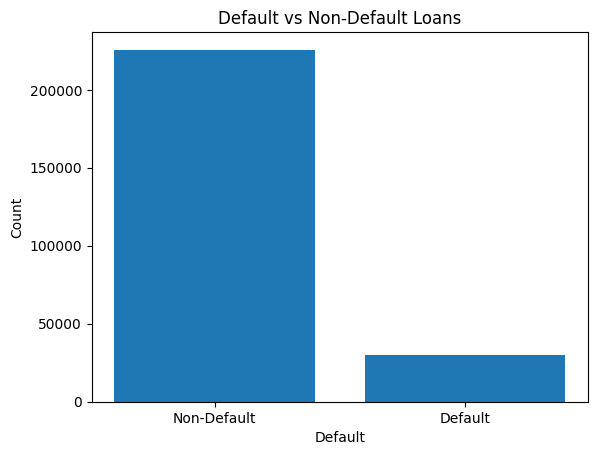

In [11]:
#count for how many borrwers defaulted vs did not default
default_counts = df['Default'].value_counts()

plt.bar(['Non-Default', 'Default'], default_counts.values)
plt.title('Default vs Non-Default Loans')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

In [12]:
#only keep numerical columns for correlation matrix
corr_matrix = df.select_dtypes(include=['number']).corr()

corr_matrix

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,Implausible_AgeEmp
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783,-0.105498
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119,0.001165
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659,-0.001231
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166,0.000127
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374,0.098597
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330,-0.000949
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273,0.000260
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545,-0.002074
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236,-0.000979
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000,0.006747


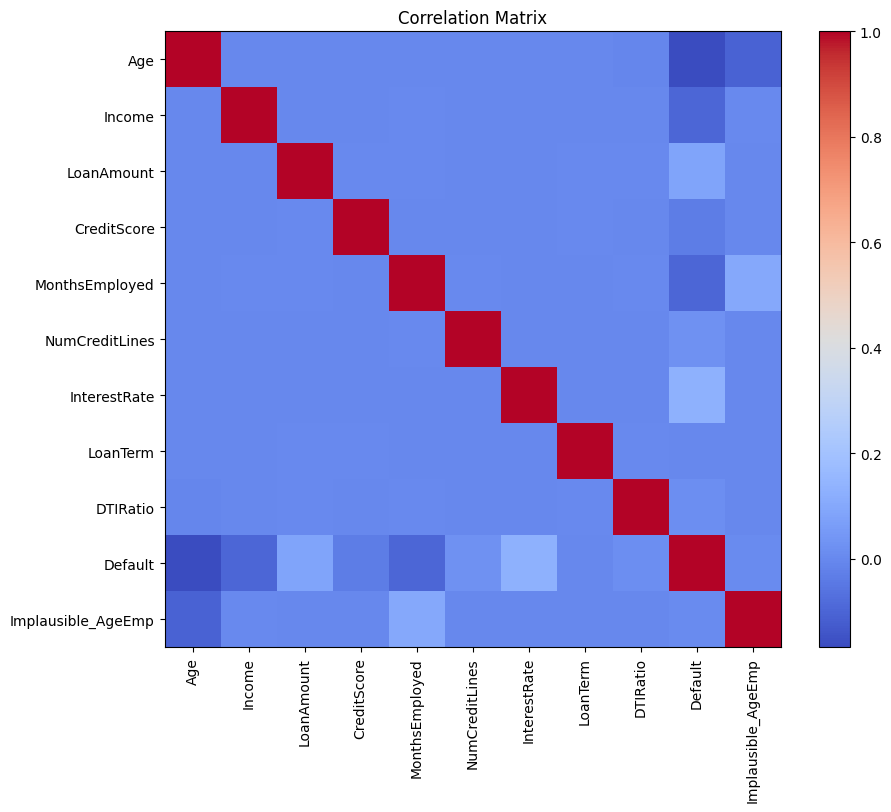

In [13]:
#to visulise correlations
plt.figure(figsize=(10,8))

plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")

plt.show()

In [14]:
#to see and compare the average values for defaultes vs non-defaulters to easily spot differences
default_means = df.groupby('Default')[['Income', 'CreditScore', 'InterestRate', 'DTIRatio', 'LoanAmount', 'MonthsEmployed']].mean()

default_means

,Income,CreditScore,InterestRate,DTIRatio,LoanAmount,MonthsEmployed
Default,,,,,,
0,83899.165995,576.232270,13.176994,0.498602,125353.656017,60.764721
1,71844.722659,559.286143,15.896227,0.512467,144515.311469,50.235457


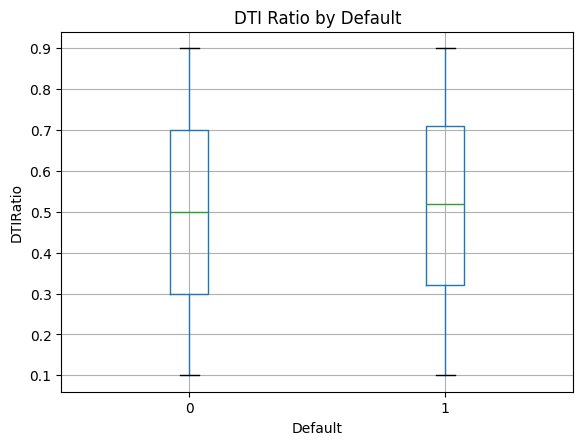

In [15]:
#compare DTI for defaulters and non-defauters
df.boxplot(column='DTIRatio', by='Default')

plt.title('DTI Ratio by Default')
plt.suptitle('')
plt.xlabel('Default')
plt.ylabel('DTIRatio')

plt.show()

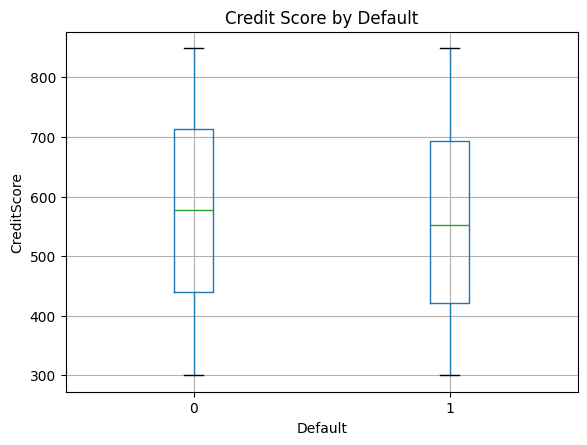

In [16]:
#compare credit score between default and nondefault
df.boxplot(column='CreditScore', by='Default')

plt.title('Credit Score by Default')
plt.suptitle('')
plt.xlabel('Default')
plt.ylabel('CreditScore')

plt.show()

In [17]:
#make a copy so original is untocuhed
df_ml = df.copy()
df_ml = df_ml.drop(columns=['LoanID'], errors='ignore')

#turn catagorical columns into dummy variable numbers for the model
df_ml = pd.get_dummies(df_ml, drop_first=True)

X = df_ml.drop(columns=['Default'])
y = df_ml['Default']

In [18]:
#split dataset for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#balance training data with ROS
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

In [19]:
#scale before modelling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
#quick check to see it working^
pd.Series(y_train).value_counts()

,count
Default,
0,180633
1,180633


In [21]:
#train log reg model
#max_iter gives iterations to converge
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [22]:
#train rand forest, 100trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [23]:
#train gradient boosting
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [24]:
#logistic regression
y_train_pred_log = log_model.predict(X_train)

print("Logistic Regression Train Accuracy:", accuracy_score(y_train, y_train_pred_log))
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

print("\n-----------------------------------\n")

#Random forest
y_train_pred_rf = rf_model.predict(X_train)

print("Random Forest Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\n-----------------------------------\n")

#gradient boosting
y_train_pred_gb = gb_model.predict(X_train)

print("Gradient Boosting Train Accuracy:", accuracy_score(y_train, y_train_pred_gb))
print("Gradient Boosting Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Logistic Regression Train Accuracy: 0.6819047460873705
Logistic Regression Test Accuracy: 0.6742901899353828
Logistic Regression Confusion Matrix:
[[30259 14802]
 [ 1832  4177]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     45061
           1       0.22      0.70      0.33      6009

    accuracy                           0.67     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.67      0.73     51070


-----------------------------------

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.8838065400430781
Random Forest Confusion Matrix:
[[44672   389]
 [ 5545   464]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45061
           1       0.54      0.08      0.14      6009

    accuracy                           0.88     51070
   macro avg  